In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ══════════════════════════════════════════════════════
# Q4 — IMAGE FEATURES (GÖRÜNTÜ ÖZELLİKLERİ)
# ══════════════════════════════════════════════════════
#
# Şimdiye kadar hep ham piksel kullandık:
#   Her görüntü = 32×32×3 = 3072 sayı (piksel değerleri)
#
# Problem: Ham piksel kötü bir temsil!
#   Aynı kedi → farklı ışık → pikseller çok farklı
#   Aynı kedi → farklı açı  → pikseller çok farklı
#   ama ikisi de kedi!
#
# Çözüm: Ham piksel yerine ÖZELLIK çıkar
#   Özellik = görüntünün daha anlamlı temsili
#
# Bu derste 2 özellik kullanıyoruz:
#   1. HOG (Histogram of Oriented Gradients)
#      → Kenarları ve şekilleri yakalar
#   2. Color Histogram
#      → Renk dağılımını yakalar
# ══════════════════════════════════════════════════════

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ══════════════════════════════════════════════════════
# HAM PİKSEL NEDEN KÖTÜ?
# ══════════════════════════════════════════════════════
#
# Basit örnek: 2 piksellik görüntüler
#
#   Kedi 1: [200, 180]  ← aydınlık ortamda , iki piksel 1.piksel=200 (çok aydınlık) 2.piksel=180 (aydınlık)
#   Kedi 2: [100, 90]   ← karanlık ortamda (aynı kedi!)
#   Köpek:  [190, 170]  ← aydınlık ortamda
#
# Ham piksel mesafesi:
#   Kedi1 - Kedi2 = 141  ← UZAK! (ama aynı hayvan)
#   Kedi1 - Köpek =  14  ← YAKIN! (farklı hayvan)
#
# kNN ham piksel kullanırsa köpeği kedi sanır!
# ══════════════════════════════════════════════════════

kedi1 = np.array([200, 180])   # aydınlık kedi
kedi2 = np.array([100, 90])    # karanlık kedi
kopek = np.array([190, 170])   # aydınlık köpek

# Ham piksel mesafeleri
d_kedi = np.sqrt(np.sum((kedi1 - kedi2)**2))
d_kopek = np.sqrt(np.sum((kedi1 - kopek)**2))

print("=== HAM PİKSEL MESAFELERİ ===")
print(f"Kedi1 → Kedi2 (aynı hayvan): {d_kedi:.1f}")
print(f"Kedi1 → Köpek (farklı hayvan): {d_kopek:.1f}")
print(f"\nSorun: Köpek kediye daha YAKIN görünüyor!")

# Çözüm: Normalize et (parlaklıktan bağımsız hale getir)
kedi1_norm = kedi1 / np.linalg.norm(kedi1)
kedi2_norm = kedi2 / np.linalg.norm(kedi2)
kopek_norm = kopek / np.linalg.norm(kopek)

d_kedi_norm = np.sqrt(np.sum((kedi1_norm - kedi2_norm)**2))
d_kopek_norm = np.sqrt(np.sum((kedi1_norm - kopek_norm)**2))

print("\n=== NORMALİZE EDİLMİŞ MESAFELERİ ===")
print(f"Kedi1 → Kedi2 (aynı hayvan): {d_kedi_norm:.4f}")
print(f"Kedi1 → Köpek (farklı hayvan): {d_kopek_norm:.4f}")
print(f"\nDüzeldi: Artık kediler birbirine daha YAKIN!")

=== HAM PİKSEL MESAFELERİ ===
Kedi1 → Kedi2 (aynı hayvan): 134.5
Kedi1 → Köpek (farklı hayvan): 14.1

Sorun: Köpek kediye daha YAKIN görünüyor!

=== NORMALİZE EDİLMİŞ MESAFELERİ ===
Kedi1 → Kedi2 (aynı hayvan): 0.0000
Kedi1 → Köpek (farklı hayvan): 0.0029

Düzeldi: Artık kediler birbirine daha YAKIN!


Görüntü:
[[  0.   0. 255. 255. 255.]
 [  0.   0. 255. 255. 255.]
 [  0.   0. 255. 255. 255.]
 [  0.   0. 255. 255. 255.]
 [  0.   0. 255. 255. 255.]]

Yatay gradient (kenarlar):
[[  0. 255.   0.   0.]
 [  0. 255.   0.   0.]
 [  0. 255.   0.   0.]
 [  0. 255.   0.   0.]
 [  0. 255.   0.   0.]]

Gördün mü? Kenar olan yerde büyük değer çıkıyor!


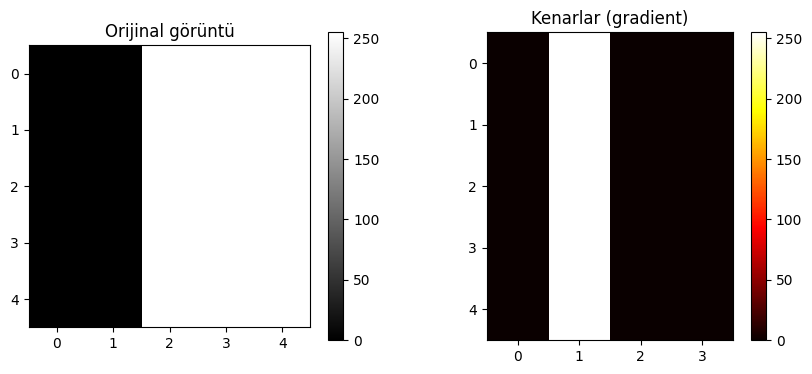

In [5]:
# ══════════════════════════════════════════════════════
# HOG — HISTOGRAM OF ORIENTED GRADIENTS
# ══════════════════════════════════════════════════════
#
# HOG ne yapar?
#   Görüntüdeki KENARLARI ve ŞEKILLERI yakalar
#   Piksel değil, kenar yönlerini kullanır
#
# Neden daha iyi?
#   Kedi her zaman kedi şeklinde kenarlar oluşturur
#   Işık değişse de kenarlar benzer kalır!
#
# Nasıl çalışır?
#   1. Her pikselin komşularıyla farkını al → gradient
#   2. Gradient'in yönünü hesapla (0-180 derece)
#   3. Yönleri histogram'a koy
#   4. Bu histogram = görüntünün HOG özelliği
#
# Basit örnek — gradient hesaplama:
# ══════════════════════════════════════════════════════

# Basit 5x5 görüntü — sol karanlık, sağ aydınlık
goruntu = np.array([
    [0,  0,  255, 255, 255],
    [0,  0,  255, 255, 255],
    [0,  0,  255, 255, 255],
    [0,  0,  255, 255, 255],
    [0,  0,  255, 255, 255],
], dtype=float)

# Yatay gradient — sağa doğru fark
# Kenar nerede? Siyah-beyaz geçişinde!
grad_x = np.diff(goruntu, axis=1)  # sütun farkı
print("Görüntü:")
print(goruntu)
print("\nYatay gradient (kenarlar):")
print(grad_x)
print("\nGördün mü? Kenar olan yerde büyük değer çıkıyor!")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(goruntu, cmap='gray')
plt.title("Orijinal görüntü")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(np.abs(grad_x), cmap='hot')
plt.title("Kenarlar (gradient)")
plt.colorbar()
plt.show()

In [7]:
# Aydınlık görüntü
aydinlik = np.array([
    [50,  50,  200, 200, 200],
    [50,  50,  200, 200, 200],
    [50,  50,  200, 200, 200],
    [50,  50,  200, 200, 200],
    [50,  50,  200, 200, 200],
], dtype=float)

# Aynı şekil ama yarı parlaklıkta
karanlik = aydinlik / 2

# Ham piksel mesafesi
ham_mesafe = np.sqrt(np.sum((aydinlik - karanlik)**2))
print(f"Ham piksel mesafesi: {ham_mesafe:.1f}  ← büyük!")

# HOG — gradient kullan
def basit_hog(img):
    grad_x = np.diff(img, axis=1)
    grad_y = np.diff(img, axis=0)
    grad_x = grad_x / (np.max(np.abs(grad_x)) + 1e-8)
    grad_y = grad_y / (np.max(np.abs(grad_y)) + 1e-8)
    return np.concatenate([grad_x.flatten(), grad_y.flatten()])

hog_aydinlik = basit_hog(aydinlik)
hog_karanlik = basit_hog(karanlik)

hog_mesafe = np.sqrt(np.sum((hog_aydinlik - hog_karanlik)**2))
print(f"HOG mesafesi:        {hog_mesafe:.1f}  ← küçük! (şekil aynı)")

Ham piksel mesafesi: 395.3  ← büyük!
HOG mesafesi:        0.0  ← küçük! (şekil aynı)


In [8]:
# ══════════════════════════════════════════════════════
# COLOR HISTOGRAM — RENK DAĞILIMI
# ══════════════════════════════════════════════════════
#
# Color Histogram ne yapar?
#   Görüntüdeki renklerin dağılımını yakalar
#   "Bu görüntüde ne kadar kırmızı, yeşil, mavi var?"
#
# Neden faydalı?
#   Gökyüzü → çok mavi
#   Çimen   → çok yeşil
#   Ateş    → çok kırmızı/sarı
#
# Piksel konumundan bağımsız!
#   Kedi sola kaysa da sağa kaysa da
#   renk dağılımı benzer kalır
# ══════════════════════════════════════════════════════

# 2 farklı görüntü oluştur
np.random.seed(0)

# Gökyüzü görüntüsü — çok mavi
goksuyu = np.zeros((5, 5, 3), dtype=int)
goksuyu[:, :, 2] = np.random.randint(150, 255, (5, 5))  # mavi kanal yüksek
goksuyu[:, :, 0] = np.random.randint(0, 50, (5, 5))     # kırmızı düşük
goksuyu[:, :, 1] = np.random.randint(0, 50, (5, 5))     # yeşil düşük

# Çimen görüntüsü — çok yeşil
cimen = np.zeros((5, 5, 3), dtype=int)
cimen[:, :, 1] = np.random.randint(150, 255, (5, 5))    # yeşil kanal yüksek
cimen[:, :, 0] = np.random.randint(0, 50, (5, 5))       # kırmızı düşük
cimen[:, :, 2] = np.random.randint(0, 50, (5, 5))       # mavi düşük

# Color histogram hesapla
def color_histogram(img, bins=8):
    # Her renk kanalı için histogram
    hist_r = np.histogram(img[:,:,0], bins=bins, range=(0,255))[0]
    hist_g = np.histogram(img[:,:,1], bins=bins, range=(0,255))[0]
    hist_b = np.histogram(img[:,:,2], bins=bins, range=(0,255))[0]
    # Normalize et
    hist = np.concatenate([hist_r, hist_g, hist_b]).astype(float)
    return hist / hist.sum()

hist_goksuyu = color_histogram(goksuyu)
hist_cimen   = color_histogram(cimen)

print("Gökyüzü histogram (R, G, B):")
print(f"  Kırmızı: {hist_goksuyu[:8]}")
print(f"  Yeşil:   {hist_goksuyu[8:16]}")
print(f"  Mavi:    {hist_goksuyu[16:]}")

print("\nÇimen histogram (R, G, B):")
print(f"  Kırmızı: {hist_cimen[:8]}")
print(f"  Yeşil:   {hist_cimen[8:16]}")
print(f"  Mavi:    {hist_cimen[16:]}")

mesafe = np.sqrt(np.sum((hist_goksuyu - hist_cimen)**2))
print(f"\nColor histogram mesafesi: {mesafe:.4f}")
print("Gökyüzü ve çimen farklı renk dağılımı → mesafe büyük!")

Gökyüzü histogram (R, G, B):
  Kırmızı: [0.25333333 0.08       0.         0.         0.         0.
 0.         0.        ]
  Yeşil:   [0.17333333 0.16       0.         0.         0.         0.
 0.         0.        ]
  Mavi:    [0.         0.         0.         0.         0.01333333 0.08
 0.12       0.12      ]

Çimen histogram (R, G, B):
  Kırmızı: [0.17333333 0.16       0.         0.         0.         0.
 0.         0.        ]
  Yeşil:   [0.         0.         0.         0.         0.04       0.06666667
 0.09333333 0.13333333]
  Mavi:    [0.21333333 0.12       0.         0.         0.         0.
 0.         0.        ]

Color histogram mesafesi: 0.4430
Gökyüzü ve çimen farklı renk dağılımı → mesafe büyük!


In [10]:
# ══════════════════════════════════════════════════════
# ÖZET — HAM PİKSEL vs ÖZELLİKLER
# ══════════════════════════════════════════════════════

print("╔══════════════════════════════════════════════╗")
print("║         HAM PİKSEL vs ÖZELLİKLER             ║")
print("╠══════════════════════════════════════════════╣")
print("║                                              ║")
print("║  Ham Piksel:                                 ║")
print("║    - Işık değişince → çok farklı görünür     ║")
print("║    - Konum değişince → çok farklı görünür    ║")
print("║    - kNN ile ~%27 doğruluk                   ║")
print("║                                              ║")
print("║  HOG:                                        ║")
print("║    - Kenarları yakalar                       ║")
print("║    - Işıktan bağımsız                        ║")
print("║    - Şekli tanır                             ║")
print("║                                              ║")
print("║  Color Histogram:                            ║")
print("║    - Renk dağılımını yakalar                 ║")
print("║    - Konumdan bağımsız                       ║")
print("║    - Sahneyi tanır (gökyüzü, çimen...)       ║")
print("║                                              ║")
print("║  HOG + Color Histogram ile ~%38 doğruluk     ║")
print("║  Ham pikselden %11 daha iyi!                 ║")
print("╚══════════════════════════════════════════════╝")

╔══════════════════════════════════════════════╗
║         HAM PİKSEL vs ÖZELLİKLER             ║
╠══════════════════════════════════════════════╣
║                                              ║
║  Ham Piksel:                                 ║
║    - Işık değişince → çok farklı görünür     ║
║    - Konum değişince → çok farklı görünür    ║
║    - kNN ile ~%27 doğruluk                   ║
║                                              ║
║  HOG:                                        ║
║    - Kenarları yakalar                       ║
║    - Işıktan bağımsız                        ║
║    - Şekli tanır                             ║
║                                              ║
║  Color Histogram:                            ║
║    - Renk dağılımını yakalar                 ║
║    - Konumdan bağımsız                       ║
║    - Sahneyi tanır (gökyüzü, çimen...)       ║
║                                              ║
║  HOG + Color Histogram ile ~%38 doğruluk     ║
║  Ham pikselden %11